# Vehicle Damage Assessment — from scratch, step by step

Goal: given a photo of a car, estimate **damage severity** (none / minor /
moderate / severe) and a **repair-cost bracket**, for use in a motor
insurance claims flow.

This notebook is split into two parts:

1. **Part A — Working demo (no dataset needed).** A classical CV heuristic
   pipeline built up step by step, with visualizations at each stage, so you
   can see *why* it flags what it flags and tune it as you go.
2. **Part B — Training pipeline scaffold.** A transfer-learning model
   (EfficientNet-B0 backbone) + dataset loaders, ready to fine-tune once you
   download a labeled dataset (links + setup at the bottom).

Run cells top to bottom. Swap in your own photo any time by changing
`TEST_IMAGE_PATH` in the cell below.


## Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

def show(img_bgr, title="", cmap=None):
    plt.figure()
    if cmap:
        plt.imshow(img_bgr, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


## Test images

No dataset yet, so we synthesize a rough "car photo" (clean + damaged
version) just to prove the pipeline end to end. **Swap `TEST_IMAGE_PATH` for
a real accident photo any time** — everything below works the same way.


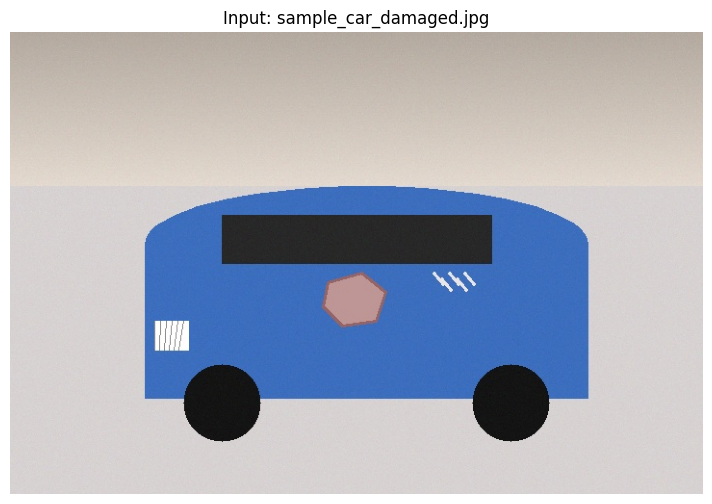

In [2]:
def make_car_image(damaged: bool = True, path: str = "sample_car.jpg"):
    h, w = 480, 720
    img = np.full((h, w, 3), (210, 210, 215), dtype=np.uint8)

    for y in range(0, 160):
        shade = int(160 + y * 0.3)
        img[y, :] = (shade, shade + 10, shade + 20)

    body_color = (190, 110, 60)  # BGR -> a blue car
    cv2.rectangle(img, (140, 220), (600, 380), body_color, -1)
    cv2.ellipse(img, (370, 220), (230, 60), 0, 180, 360, body_color, -1)
    cv2.rectangle(img, (220, 190), (500, 240), (40, 40, 40), -1)  # windows
    cv2.circle(img, (220, 385), 40, (20, 20, 20), -1)  # wheels
    cv2.circle(img, (520, 385), 40, (20, 20, 20), -1)

    noise = np.random.normal(0, 3, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    if damaged:
        pts = np.array([[330, 260], [365, 250], [390, 270], [380, 300], [345, 305], [325, 285]])
        cv2.fillPoly(img, [pts], (150, 150, 190))   # lighter irregular dent so it isn't lost in dark-tile filtering
        cv2.polylines(img, [pts], True, (100, 100, 150), 2)
        for i in range(5):
            x1, y1 = 440 + i * 8, 250 + (i % 2) * 6
            cv2.line(img, (x1, y1), (x1 + 10, y1 + 12), (230, 230, 235), 2)
        cv2.rectangle(img, (150, 300), (185, 330), (255, 255, 255), -1)
        for i in range(6):
            cv2.line(img, (150 + i * 6, 300), (150 + i * 5, 330), (140, 140, 140), 1)

    cv2.imwrite(path, img)
    return path

make_car_image(damaged=True, path="sample_car_damaged.jpg")
make_car_image(damaged=False, path="sample_car_clean.jpg")

TEST_IMAGE_PATH = "sample_car_damaged.jpg"  # <- point this at a real photo any time

img = cv2.imread(TEST_IMAGE_PATH)
show(img, f"Input: {TEST_IMAGE_PATH}")


## Step 1 — Isolate the vehicle from the background

Accident photos are usually vehicle-centered, so we seed GrabCut with a
center-biased rectangle rather than needing a trained detector.


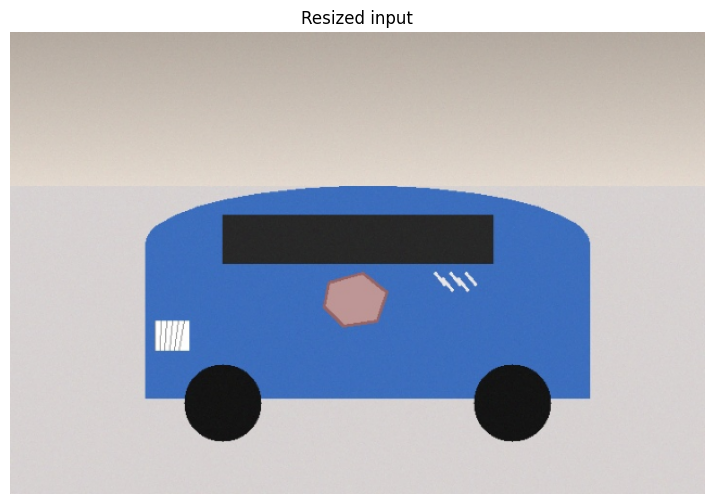

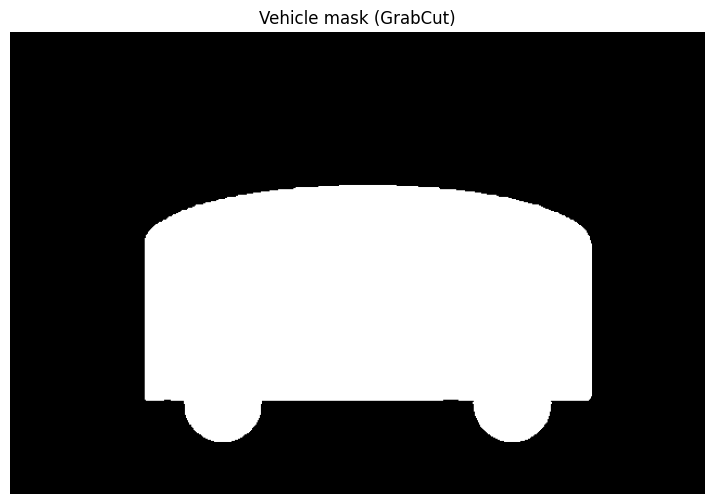

In [3]:
RESIZE_TO = 640

def segment_vehicle(img):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    margin_x, margin_y = int(w * 0.08), int(h * 0.08)
    rect = (margin_x, margin_y, w - 2 * margin_x, h - 2 * margin_y)
    try:
        cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 4, cv2.GC_INIT_WITH_RECT)
        vehicle_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    except cv2.error:
        vehicle_mask = np.zeros((h, w), np.uint8)
        vehicle_mask[margin_y:h - margin_y, margin_x:w - margin_x] = 1
    if vehicle_mask.sum() < 0.05 * h * w:
        vehicle_mask = np.zeros((h, w), np.uint8)
        vehicle_mask[margin_y:h - margin_y, margin_x:w - margin_x] = 1
    return vehicle_mask

orig_h, orig_w = img.shape[:2]
scale = RESIZE_TO / max(orig_h, orig_w)
resized = cv2.resize(img, (int(orig_w * scale), int(orig_h * scale)))

vehicle_mask = segment_vehicle(resized)
show(resized, "Resized input")
show(vehicle_mask * 255, "Vehicle mask (GrabCut)", cmap="gray")


## Step 2 — Score every region for "damage-like" anomaly

For each tile inside the vehicle mask we combine three signals:

- **Edge density** — Canny edges; damage creates irregular edges
- **Texture variance** — Laplacian variance; dents/cracks break the smooth
  gradient a healthy panel has
- **Color irregularity** — local std-dev; scratches/rust/mismatched paint
  stand out locally

Two corrections keep this from just flagging *every* car's normal features:

- **Erode + drop the bottom band of the mask** — wheels and the
  silhouette-vs-road boundary have strong natural contrast that has nothing
  to do with damage
- **Drop very dark tiles** — window glass/tire interiors are naturally dark
  and edge-heavy; they aren't painted panel


104 tiles scored


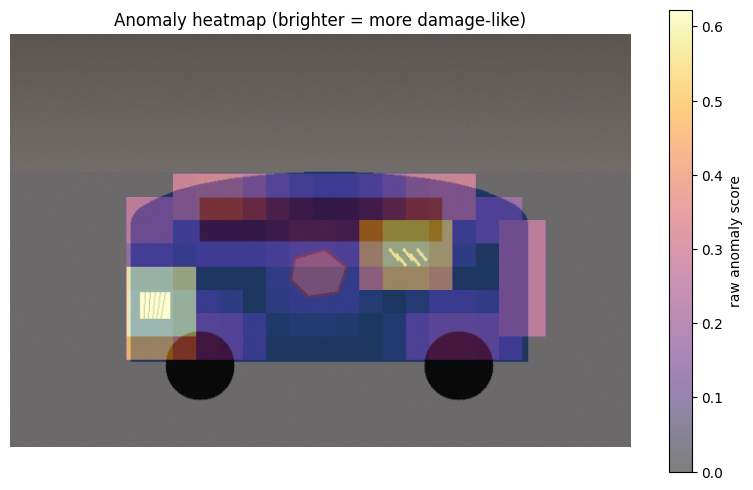

In [4]:
TILE_SIZE = 48
ANOMALY_PERCENTILE = 85

def tile_anomaly_scores(gray, mask, tile=TILE_SIZE):
    h, w = gray.shape
    edges = cv2.Canny(gray, 60, 160)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)

    erode_px = max(tile // 3, 10)
    kernel = np.ones((erode_px, erode_px), np.uint8)
    mask = cv2.erode(mask, kernel)

    ys, xs = np.where(mask > 0)
    if len(ys) > 0:
        y_top, y_bottom = ys.min(), ys.max()
        wheel_line = y_top + int(0.80 * (y_bottom - y_top))
        mask[wheel_line:, :] = 0

    scored = []
    for y in range(0, h - tile, tile // 2):
        for x in range(0, w - tile, tile // 2):
            if mask[y:y + tile, x:x + tile].mean() < 0.5:
                continue
            gray_tile = gray[y:y + tile, x:x + tile]
            if gray_tile.mean() < 45:
                continue
            edge_tile = edges[y:y + tile, x:x + tile]
            lap_tile = laplacian[y:y + tile, x:x + tile]

            edge_density = edge_tile.mean() / 255.0
            texture_score = min(lap_tile.var() / 800.0, 1.0)
            color_score = min(gray_tile.std() / 60.0, 1.0)

            raw_score = 0.45 * edge_density + 0.35 * texture_score + 0.20 * color_score
            scored.append(((x, y, tile, tile), raw_score))
    return scored

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
gray = cv2.bilateralFilter(gray, 7, 50, 50)

scored_tiles = tile_anomaly_scores(gray, vehicle_mask)
print(f"{len(scored_tiles)} tiles scored")

# visualize as a heatmap
heat = np.zeros(gray.shape, dtype=np.float32)
for (x, y, tw, th), s in scored_tiles:
    heat[y:y+th, x:x+tw] = np.maximum(heat[y:y+th, x:x+tw], s)

plt.figure()
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.imshow(heat, cmap="inferno", alpha=0.5)
plt.title("Anomaly heatmap (brighter = more damage-like)")
plt.axis('off')
plt.colorbar(label="raw anomaly score")
plt.show()


## Step 3 — Threshold, merge into regions, classify severity

Threshold is **relative to this vehicle's own baseline** (the calmest
quartile of its own tiles = assumed healthy panel), not a fixed percentile
of every image — otherwise normal features every car has would always get
flagged on a perfectly healthy car.


In [5]:
@dataclass
class DamageRegion:
    bbox: Tuple[int, int, int, int]
    score: float

def merge_boxes(boxes, scores):
    if not boxes:
        return []
    rects = [[x, y, x + w, y + h] for x, y, w, h in boxes]
    used = [False] * len(rects)
    merged = []
    def overlaps(a, b):
        return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])
    for i in range(len(rects)):
        if used[i]:
            continue
        group = [i]; used[i] = True; changed = True
        while changed:
            changed = False
            for j in range(len(rects)):
                if used[j]:
                    continue
                if any(overlaps(rects[k], rects[j]) for k in group):
                    group.append(j); used[j] = True; changed = True
        xs1 = [rects[k][0] for k in group]; ys1 = [rects[k][1] for k in group]
        xs2 = [rects[k][2] for k in group]; ys2 = [rects[k][3] for k in group]
        x1, y1, x2, y2 = min(xs1), min(ys1), max(xs2), max(ys2)
        avg_score = float(np.mean([scores[k] for k in group]))
        merged.append(DamageRegion(bbox=(x1, y1, x2 - x1, y2 - y1), score=avg_score))
    merged.sort(key=lambda r: r.score, reverse=True)
    return merged[:8]

def classify_severity(damage_area_pct, region_scores):
    if damage_area_pct < 2.5 or not region_scores:
        return "none", 0.55
    max_score = max(region_scores)
    if damage_area_pct >= 18 or max_score >= 0.68:
        return "severe", min(0.9, 0.45 + damage_area_pct / 45)
    if damage_area_pct >= 8 or max_score >= 0.55:
        return "moderate", min(0.85, 0.4 + damage_area_pct / 35)
    return "minor", min(0.8, 0.35 + damage_area_pct / 30)

scores = np.array([s for _, s in scored_tiles])
baseline = np.percentile(scores, 25)
spread = max(np.std(scores), 0.03)
percentile_threshold = np.percentile(scores, ANOMALY_PERCENTILE)
z_threshold = baseline + 1.4 * spread
threshold = max(percentile_threshold, z_threshold)
abs_floor = 0.42

damaged_tiles = [(b, s) for b, s in scored_tiles if s >= threshold and s > abs_floor]
regions = merge_boxes([b for b, _ in damaged_tiles], [s for _, s in damaged_tiles])

total_vehicle_px = vehicle_mask.sum()
damaged_px = sum(r.bbox[2] * r.bbox[3] for r in regions)
damage_area_pct = 0.0 if total_vehicle_px == 0 else min(100.0, 100.0 * damaged_px / total_vehicle_px)

severity, confidence = classify_severity(damage_area_pct, [r.score for r in regions])
print(f"severity={severity}  confidence={confidence:.2f}  damaged_area={damage_area_pct:.1f}%  regions={len(regions)}")


severity=moderate  confidence=0.85  damaged_area=16.9%  regions=2


## Step 4 — Cost bracket + annotated output

Estimated repair cost: Rs.8,000 - Rs.35,000  ($100 - $425)


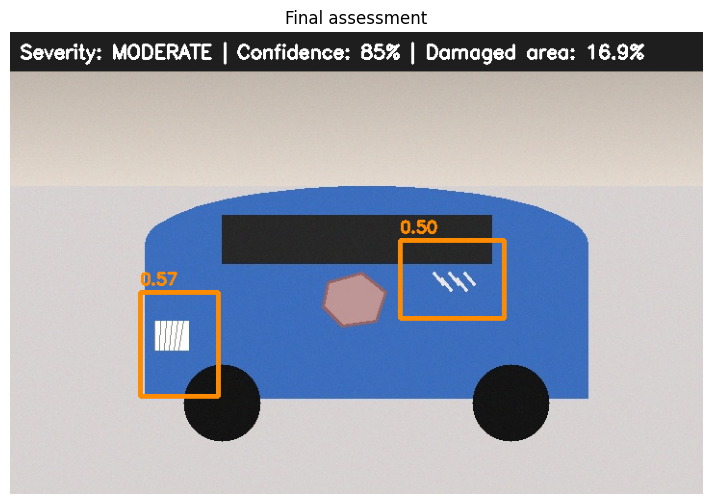

In [6]:
COST_BRACKETS = {
    "minor":    {"cost_range_inr": (1500, 8000),    "cost_range_usd": (20, 100)},
    "moderate": {"cost_range_inr": (8000, 35000),   "cost_range_usd": (100, 425)},
    "severe":   {"cost_range_inr": (35000, 150000), "cost_range_usd": (425, 1800)},
}

def draw_annotations(img, regions, severity, confidence, damage_area_pct, scale):
    out = img.copy()
    color_map = {"minor": (0, 200, 255), "moderate": (0, 140, 255), "severe": (0, 0, 255), "none": (0, 200, 0)}
    color = color_map.get(severity, (255, 255, 255))
    inv_scale = 1.0 / scale
    for r in regions:
        x, y, w, h = [int(v * inv_scale) for v in r.bbox]
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 3)
        cv2.putText(out, f"{r.score:.2f}", (x, max(y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    banner = f"Severity: {severity.upper()} | Confidence: {confidence*100:.0f}% | Damaged area: {damage_area_pct:.1f}%"
    cv2.rectangle(out, (0, 0), (out.shape[1], 40), (30, 30, 30), -1)
    cv2.putText(out, banner, (10, 27), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
    return out

bracket = COST_BRACKETS.get(severity, {"cost_range_inr": (0, 0), "cost_range_usd": (0, 0)})
print(f"Estimated repair cost: Rs.{bracket['cost_range_inr'][0]:,} - Rs.{bracket['cost_range_inr'][1]:,}"
      f"  (${bracket['cost_range_usd'][0]} - ${bracket['cost_range_usd'][1]})" if severity != "none" else "No repair needed")

annotated = draw_annotations(img, regions, severity, confidence, damage_area_pct, scale)
show(annotated, "Final assessment")


## Step 5 — Wrap it into one function, sanity-check clean vs. damaged

This is the exact function you'd import into a FastAPI/Flask backend
(`assess_image(image_bytes) -> AssessmentResult, annotated_image`).


sample_car_clean.jpg -> {'severity': 'none', 'confidence': 0.55, 'damage_area_pct': 0.0, 'regions': 0, 'cost_estimate_inr': (0, 0)}


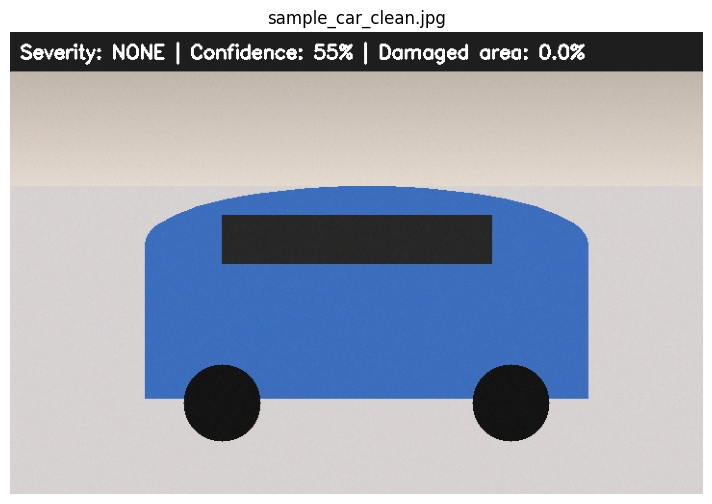

sample_car_damaged.jpg -> {'severity': 'moderate', 'confidence': 0.85, 'damage_area_pct': 16.9, 'regions': 2, 'cost_estimate_inr': (8000, 35000)}


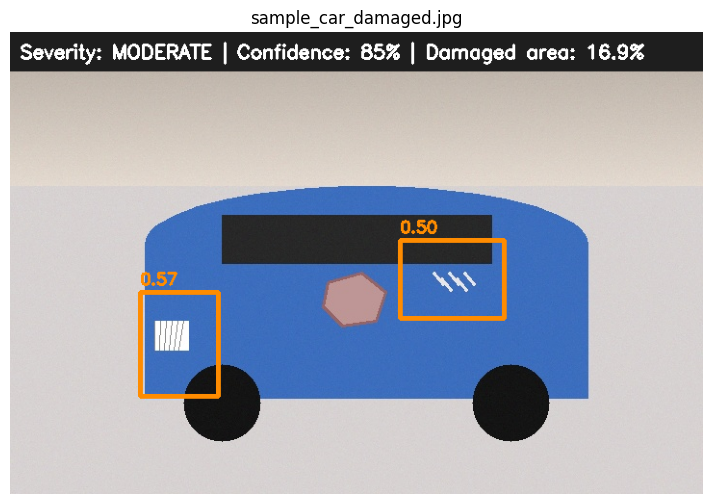

In [7]:
def assess_image(image_bytes):
    arr = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Could not decode image")

    orig_h, orig_w = img.shape[:2]
    scale = RESIZE_TO / max(orig_h, orig_w)
    resized = cv2.resize(img, (int(orig_w * scale), int(orig_h * scale)))
    gray = cv2.bilateralFilter(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), 7, 50, 50)

    vehicle_mask = segment_vehicle(resized)
    scored_tiles = tile_anomaly_scores(gray, vehicle_mask)
    if not scored_tiles:
        return {"severity": "none", "confidence": 0.0, "damage_area_pct": 0.0, "regions": []}, img

    scores = np.array([s for _, s in scored_tiles])
    baseline = np.percentile(scores, 25)
    spread = max(np.std(scores), 0.03)
    threshold = max(np.percentile(scores, ANOMALY_PERCENTILE), baseline + 1.4 * spread)
    damaged_tiles = [(b, s) for b, s in scored_tiles if s >= threshold and s > 0.42]
    regions = merge_boxes([b for b, _ in damaged_tiles], [s for _, s in damaged_tiles])

    total_vehicle_px = vehicle_mask.sum()
    damaged_px = sum(r.bbox[2] * r.bbox[3] for r in regions)
    damage_area_pct = 0.0 if total_vehicle_px == 0 else min(100.0, 100.0 * damaged_px / total_vehicle_px)
    severity, confidence = classify_severity(damage_area_pct, [r.score for r in regions])

    annotated = draw_annotations(img, regions, severity, confidence, damage_area_pct, scale)
    result = {
        "severity": severity, "confidence": round(confidence, 2),
        "damage_area_pct": round(damage_area_pct, 1), "regions": len(regions),
        "cost_estimate_inr": COST_BRACKETS.get(severity, {}).get("cost_range_inr", (0, 0)),
    }
    return result, annotated

for path in ["sample_car_clean.jpg", "sample_car_damaged.jpg"]:
    with open(path, "rb") as f:
        result, annotated = assess_image(f.read())
    print(path, "->", result)
    show(annotated, path)


## Try your own photo

Uncomment and run this cell if you're working in JupyterLab/Notebook
locally (the upload widget needs a live ipywidgets frontend — it won't do
anything in a plain script export).


In [8]:
# import ipywidgets as widgets
# from IPython.display import display
#
# uploader = widgets.FileUpload(accept='image/*', multiple=False)
# display(uploader)
#
# def run_on_upload(change):
#     if not uploader.value:
#         return
#     item = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
#     content = item['content'] if isinstance(item, dict) else item.content
#     result, annotated = assess_image(bytes(content))
#     print(result)
#     show(annotated, "Your photo")
#
# uploader.observe(run_on_upload, names='value')


### Or test on a real photo from your downloaded dataset

If you've already downloaded the Kaggle Car Damage Severity Dataset into
`data/` (see Part B below for the folder layout it expects), you don't need
to wait for training to try the heuristic on a real photo — just point it at
any file already sitting in there.


468 images in data/training/03-severe, e.g.: ['0001.JPEG', '0002.JPEG', '0003.JPEG', '0004.JPEG', '0005.JPEG']
{'severity': 'none', 'confidence': 0.55, 'damage_area_pct': 0.0, 'regions': 0, 'cost_estimate_inr': (0, 0)}


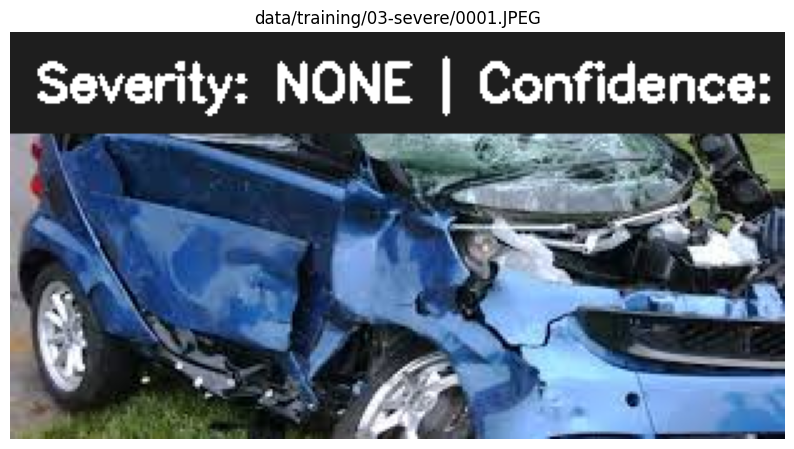

In [9]:
import os

real_data_dir = "data/training/03-severe"  # change to 01-minor / 02-moderate to compare

if os.path.isdir(real_data_dir):
    sample_files = [f for f in os.listdir(real_data_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"{len(sample_files)} images in {real_data_dir}, e.g.: {sample_files[:5]}")

    if sample_files:
        real_test_path = os.path.join(real_data_dir, sample_files[0])
        with open(real_test_path, "rb") as f:
            result, annotated = assess_image(f.read())
        print(result)
        show(annotated, real_test_path)
else:
    print(f"'{real_data_dir}' not found yet — download the dataset into data/ first (see Part B).")


---
# Part B — Training pipeline scaffold

Once you have a labeled dataset (see links at the very bottom), swap the
heuristic above for a learned model. This section defines the architecture
and dataset loaders; it's written to run standalone once `torch`/
`torchvision` are installed and `DATA_ROOT` points at real data.

**Design choice:** two heads sharing one EfficientNet-B0 backbone —
`severity` (4-way) and `damage_type` (multi-label: scratch/dent/crack/
glass_shatter/lamp_broken/tire_flat). Repair cost is deliberately **not**
regressed directly by the CNN — bolt an XGBoost regressor on top that takes
`[severity, damage_types, area_pct]` as tabular features, which is far
easier to calibrate to real repair pricing and matches the published
approach for this exact problem (CNN/YOLO for perception + XGBoost for cost).


In [10]:
# Uncomment to install (large download — several hundred MB)
# !pip install --break-system-packages torch torchvision --quiet


In [11]:
import torch
import torch.nn as nn

SEVERITY_CLASSES = ["none", "minor", "moderate", "severe"]
DAMAGE_TYPES = ["scratch", "dent", "crack", "glass_shatter", "lamp_broken", "tire_flat"]

class VehicleDamageNet(nn.Module):
    def __init__(self, backbone="efficientnet_b0", pretrained=True, freeze_backbone=True):
        super().__init__()
        import torchvision.models as models
        if backbone == "efficientnet_b0":
            weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            base = models.efficientnet_b0(weights=weights)
            feat_dim = base.classifier[1].in_features
            base.classifier = nn.Identity()
        elif backbone == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            base = models.resnet50(weights=weights)
            feat_dim = base.fc.in_features
            base.fc = nn.Identity()
        else:
            raise ValueError(backbone)

        self.backbone = base
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        hidden = 256
        self.shared = nn.Sequential(nn.Linear(feat_dim, hidden), nn.ReLU(inplace=True), nn.Dropout(0.3))
        self.severity_head = nn.Linear(hidden, len(SEVERITY_CLASSES))
        self.damage_type_head = nn.Linear(hidden, len(DAMAGE_TYPES))

    def forward(self, x):
        feats = self.backbone(x)
        shared = self.shared(feats)
        return {"severity_logits": self.severity_head(shared), "damage_type_logits": self.damage_type_head(shared)}

    def unfreeze_backbone(self, last_n_blocks=2):
        children = list(self.backbone.children())
        for block in children[-last_n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

# quick shape check
m = VehicleDamageNet(pretrained=False)  # pretrained=False here just to skip a slow weights download; use True for real training
out = m(torch.randn(2, 3, 224, 224))
print(out["severity_logits"].shape, out["damage_type_logits"].shape)


torch.Size([2, 4]) torch.Size([2, 6])


### Dataset loader

Expects either:

- **Folder layout**: `data/train/{none,minor,moderate,severe}/*.jpg` — matches
  the *Car Damage Severity Dataset* directly
- **COCO-style layout**: `data/images/*.jpg` + `data/annotations.json` —
  matches *COCO Car Damage Detection* / *Car Parts and Car Damages*; edit
  `CATEGORY_TO_TYPE` below to match your downloaded dataset's category names


In [12]:
import os, json
from collections import defaultdict
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((256, 256)), transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
EVAL_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SeverityFolderDataset(Dataset):
    """split is just appended to root (e.g. "training"/"validation" for the
    Kaggle Car Damage Severity Dataset, or "train"/"val" for others).

    Class-folder matching is substring-based rather than exact, so
    Kaggle's "01-minor", "02-moderate", "03-severe" naming works without
    renaming anything on disk — as does a plain "minor"/"moderate"/"severe".
    """
    def __init__(self, root, split, transform=None):
        self.root = os.path.join(root, split)
        self.transform = transform or (TRAIN_TRANSFORMS if split.startswith("train") else EVAL_TRANSFORMS)
        self.samples = []

        if not os.path.isdir(self.root):
            raise FileNotFoundError(f"{self.root} doesn't exist — check DATA_ROOT and the split name.")

        available_dirs = [d for d in os.listdir(self.root) if os.path.isdir(os.path.join(self.root, d))]

        for cls_idx, cls_name in enumerate(SEVERITY_CLASSES):
            matches = [d for d in available_dirs if cls_name in d.lower()]
            if not matches:
                continue
            cls_dir = os.path.join(self.root, matches[0])
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(cls_dir, fname), cls_idx))

        if not self.samples:
            raise FileNotFoundError(
                f"No images matched under {self.root}. Found folders: {available_dirs}. "
                f"Expected folder names containing one of {SEVERITY_CLASSES}."
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, severity_idx = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return {"image": img, "severity": torch.tensor(severity_idx, dtype=torch.long),
                "damage_types": torch.zeros(len(DAMAGE_TYPES)), "has_type_labels": torch.tensor(0.0)}

CATEGORY_TO_TYPE = {
    "scratch": "scratch", "dent": "dent", "crack": "crack",
    "glass shatter": "glass_shatter", "glass_shatter": "glass_shatter",
    "lamp broken": "lamp_broken", "headlamp_broken": "lamp_broken",
    "tire flat": "tire_flat", "flat_tire": "tire_flat",
}
TYPE_TO_SEVERITY_WEIGHT = {"scratch": 1, "dent": 2, "crack": 2, "glass_shatter": 3, "lamp_broken": 3, "tire_flat": 2}

class CocoDamageDataset(Dataset):
    def __init__(self, root, split="train", transform=None, val_fraction=0.15):
        self.image_dir = os.path.join(root, "images")
        with open(os.path.join(root, "annotations.json")) as f:
            coco = json.load(f)
        cat_id_to_name = {c["id"]: c["name"].lower() for c in coco["categories"]}
        img_id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}
        types_by_image = defaultdict(set)
        for ann in coco["annotations"]:
            mapped = CATEGORY_TO_TYPE.get(cat_id_to_name.get(ann["category_id"], ""))
            if mapped:
                types_by_image[ann["image_id"]].add(mapped)
        all_ids = sorted(img_id_to_file.keys())
        split_point = int(len(all_ids) * (1 - val_fraction))
        ids = all_ids[:split_point] if split == "train" else all_ids[split_point:]
        self.samples = []
        for img_id in ids:
            types_present = types_by_image.get(img_id, set())
            severity_idx = self._severity(types_present)
            type_vec = [1.0 if t in types_present else 0.0 for t in DAMAGE_TYPES]
            self.samples.append((os.path.join(self.image_dir, img_id_to_file[img_id]), severity_idx, type_vec))
        self.transform = transform or (TRAIN_TRANSFORMS if split == "train" else EVAL_TRANSFORMS)

    @staticmethod
    def _severity(types_present):
        if not types_present:
            return SEVERITY_CLASSES.index("none")
        w = max(TYPE_TO_SEVERITY_WEIGHT.get(t, 1) for t in types_present)
        return SEVERITY_CLASSES.index("severe" if w >= 3 else "moderate" if w == 2 else "minor")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, severity_idx, type_vec = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return {"image": img, "severity": torch.tensor(severity_idx, dtype=torch.long),
                "damage_types": torch.tensor(type_vec, dtype=torch.float32), "has_type_labels": torch.tensor(1.0)}

# --- If you downloaded the Kaggle "Car Damage Severity Dataset", its folders
# are named training/validation (not train/val) with 01-minor/02-moderate/
# 03-severe class subfolders — SeverityFolderDataset's substring matching
# handles the numeric prefixes automatically. Uncomment to load it:

DATA_ROOT = "data"
if os.path.isdir(DATA_ROOT):
    train_ds = SeverityFolderDataset(DATA_ROOT, "training")
    val_ds = SeverityFolderDataset(DATA_ROOT, "validation")
    print(f"{len(train_ds)} training images, {len(val_ds)} validation images")
    print("class distribution (train):", {SEVERITY_CLASSES[i]: sum(1 for _, c in train_ds.samples if c == i) for i in set(c for _, c in train_ds.samples)})
else:
    print(f"No '{DATA_ROOT}' folder found yet — this is expected until you've downloaded and unzipped the dataset there.")

# For a different dataset with train/val folder names instead:
# train_ds = SeverityFolderDataset(DATA_ROOT, "train")


1383 training images, 248 validation images
class distribution (train): {'minor': 452, 'moderate': 463, 'severe': 468}


### Training loop

Two-stage fine-tuning: train the heads first with the backbone frozen
(fast, won't overfit on a small dataset), then unfreeze the last couple of
backbone blocks for a low-LR second pass.


In [13]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    severity_loss_fn = nn.CrossEntropyLoss()
    type_loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    total_loss = 0.0
    for batch in loader:
        images = batch["image"].to(device)
        severity = batch["severity"].to(device)
        damage_types = batch["damage_types"].to(device)
        has_type_labels = batch["has_type_labels"].to(device)

        optimizer.zero_grad()
        out = model(images)
        loss_severity = severity_loss_fn(out["severity_logits"], severity)
        loss_types_raw = type_loss_fn(out["damage_type_logits"], damage_types).mean(dim=1)
        loss_types = (loss_types_raw * has_type_labels).sum() / has_type_labels.sum().clamp(min=1)
        loss = loss_severity + 0.5 * loss_types
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

# --- smoke test: prove the training loop actually runs, using the 2 synthetic
# images as a toy 2-class dataset (severity: none / severe). Swap for a real
# SeverityFolderDataset once you have downloaded data — this is just to
# verify the code path end to end without needing a real dataset yet.
import shutil
for split in ["train"]:
    for cls in SEVERITY_CLASSES:
        os.makedirs(f"toy_data/{split}/{cls}", exist_ok=True)
shutil.copy("sample_car_clean.jpg", "toy_data/train/none/img1.jpg")
shutil.copy("sample_car_damaged.jpg", "toy_data/train/severe/img1.jpg")

toy_ds = SeverityFolderDataset("toy_data", "train")
toy_loader = torch.utils.data.DataLoader(toy_ds, batch_size=2, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
toy_model = VehicleDamageNet(pretrained=False).to(device)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, toy_model.parameters()), lr=1e-3)

loss = train_one_epoch(toy_model, toy_loader, optimizer, device)
print(f"smoke-test epoch: loss={loss:.4f}  (proves the training loop runs end to end)")


smoke-test epoch: loss=1.4237  (proves the training loop runs end to end)


### Real training run

This only fires if `data/` exists (from the dataset-loader cell above) —
otherwise it's skipped, no need to comment/uncomment anything by hand. On
CPU expect each epoch to take a while depending on dataset size — see the
README for the GPU swap-in.


In [14]:
\
if os.path.isdir(DATA_ROOT):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Training on: {device}")

    model = VehicleDamageNet().to(device)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    # stage 1 — frozen backbone, train the heads only
    for epoch in range(10):
        loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"epoch {epoch}: loss={loss:.4f}")

    # stage 2 — unfreeze last blocks, low-LR fine-tune
    model.unfreeze_backbone(last_n_blocks=2)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
    for epoch in range(5):
        loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"fine-tune epoch {epoch}: loss={loss:.4f}")

    torch.save(model.state_dict(), "vehicle_damage_model.pt")
    print("Saved weights to vehicle_damage_model.pt")
else:
    print(f"Skipping real training — no '{DATA_ROOT}' folder found yet.")


Training on: cpu
epoch 0: loss=0.9637
epoch 1: loss=0.7778
epoch 2: loss=0.7794
epoch 3: loss=0.7395
epoch 4: loss=0.7067
epoch 5: loss=0.6928
epoch 6: loss=0.6346
epoch 7: loss=0.6452
epoch 8: loss=0.6103
epoch 9: loss=0.5982
fine-tune epoch 0: loss=0.5559
fine-tune epoch 1: loss=0.5396
fine-tune epoch 2: loss=0.5342
fine-tune epoch 3: loss=0.5225
fine-tune epoch 4: loss=0.5583
Saved weights to vehicle_damage_model.pt


### Check real accuracy on the validation set

This is the number that actually answers "how accurate is it" — the
heuristic in Part A never had one, since it was never fit to labeled data.
This evaluates the just-trained model against `data/validation/`, which it
never saw during training.


In [15]:
\
if os.path.isdir(DATA_ROOT):
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=16, shuffle=False)
    model.eval()
    correct, total = 0, 0
    confusion = torch.zeros(len(SEVERITY_CLASSES), len(SEVERITY_CLASSES), dtype=torch.long)

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["severity"].to(device)
            preds = model(images)["severity_logits"].argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            for t, p in zip(labels.cpu(), preds.cpu()):
                confusion[t, p] += 1

    print(f"Validation accuracy: {100 * correct / max(total, 1):.1f}%  ({correct}/{total})")
    print("Confusion matrix (rows=actual, cols=predicted):")
    print("          " + "  ".join(f"{c:>8}" for c in SEVERITY_CLASSES))
    for i, row in enumerate(confusion):
        print(f"{SEVERITY_CLASSES[i]:>10}" + "  ".join(f"{v.item():>8}" for v in row))
else:
    print(f"Skipping evaluation — no '{DATA_ROOT}' folder found yet.")


Validation accuracy: 65.7%  (163/248)
Confusion matrix (rows=actual, cols=predicted):
              none     minor  moderate    severe
      none       0         0         0         0
     minor       0        58        19         5
  moderate       0        18        33        24
    severe       0         1        18        72


---
## Datasets — manual download required (Kaggle needs auth)

| Dataset | Layout | Notes |
|---|---|---|
| [Car Damage Severity Dataset](https://www.kaggle.com/datasets/prajwalbhamere/car-damage-severity-dataset) | folder-per-class | drops straight into `SeverityFolderDataset` |
| [COCO Car Damage Detection](https://www.kaggle.com/datasets/lplenka/coco-car-damage-detection-dataset) | COCO polygons | small (~80 imgs), clean, good first test of `CocoDamageDataset` |
| [Car Parts and Car Damages](https://www.kaggle.com/datasets/humansintheloop/car-parts-and-car-damages) | COCO polygons | 1,812 images, CC0 licensed — best bet for real training |
| [Car Damage Assessment](https://www.kaggle.com/datasets/hamzamanssor/car-damage-assessment) | check on download | worth a look for extra volume |

After downloading, unzip into `data/` next to this notebook matching one of
the two layouts above, then re-run the Part B cells with `DATA_ROOT = "data"`
uncommented.
